# Лаба 1.05

### Математические функции и XML

In [ ]:
from meas import *

from math import *
import numpy as np

from pprint import pprint
from lxml import etree              

# Парсим XML
dom = etree.parse('latex.xml')
xml = dom.getroot()
next = lambda x: x.pop(0).text

### Результаты измерений

In [20]:
delta_t = 0.01
delta_phi = 1

N_exp1 = 10
direct_t = DirectMultipleMeasurement([18.21, 18.24, 18.24], delta_t)

Z_exp2 = 0
phi_start_exp2 = 30
phi_exp2 = [25, 20, 15, 10, 5, 0]
direct_exp2 = [
    [40.40, 83.97, 137.03, 206.86, 298.28, 491.66],
    [40.58, 88.05, 141.00, 211.54, 299.46, 486.34],
    [42.20, 87.70, 140.71, 209.64, 301.02, 488.55]
]

phi_start_exp3 = 15
N_exp3 = 5
direct_exp3 = {
    0.5: DirectMultipleMeasurement([7.80, 7.82, 7.87], delta_t),
    1:   DirectMultipleMeasurement([7.96, 7.95, 8.04], delta_t),
    2:   DirectMultipleMeasurement([8.48, 8.48, 8.47], delta_t),
    3:   DirectMultipleMeasurement([9.04, 9.10, 9.07], delta_t),
    4:   DirectMultipleMeasurement([9.59, 9.53, 9.63], delta_t),
    5:   DirectMultipleMeasurement([10.34, 10.40, 10.38], delta_t),
    5.5: DirectMultipleMeasurement([10.83, 10.87, 10.87], delta_t),
    6:   DirectMultipleMeasurement([11.15, 11.16, 11.12], delta_t),
    6.5: DirectMultipleMeasurement([11.82, 11.86, 11.85], delta_t)
}

# Массы регулировочных грузов
m_cargo = Measurement(401 * 0.001, 2 * 0.001)
# Размер регулировочных грзов вдоль спицы
b_cargo = Measurement(40.0 * 0.001, 0.1 * 0.001)
# Расстояние между рисками
l_0 = Measurement(25.2 * 0.001, 0.2 * 0.001)
# Расстояние от оси вращения до первой риски
l_1 = Measurement(57.0 * 0.001, 0.2 * 0.001)
# Масса стержня
m_rod = Measurement(95.0 * 0.001, 0.2 * 0.001)
# Длина стержня
L_rod = Measurement(22.0 * 0.01, 0.2 * 0.01)
# Расстояние от оси вращения до точки крепления стержня
r_rod = Measurement(25.0 * 0.001, 0.2 * 0.001)
# Масса ступицы
m_hub = Measurement(393 * 0.001, 0.5 * 0.001)
# Радиус ступицы
r_hub = Measurement(24.0 * 0.001, 0.2 * 0.001)

### 1 задание

##### Период колебаний

$t_\text{ср} = \frac{t_1 + t_2 + t_3}{3}, \Delta_{t_\text{ср}}=DMM$

$T = \frac{t_\text{ср}}{10}, \Delta_{T}=\frac{\Delta_{t_\text{ср}}}{10}$

In [21]:
print(f'Среднее время {N_exp1} колебаний t =' , direct_t)
T = Measurement(direct_t._value_ / N_exp1, direct_t._delta_ / N_exp1)
print('Период колебания маятника T =', T)

Среднее время 10 колебаний t = 18.23±0.04 ε = 0.24 (18.23 Δ = 0.043513727 ε = 0.238692963)
Период колебания маятника T = 1.823±0.004 ε = 0.24 (1.823 Δ = 0.004351373 ε = 0.238692963)


##### Данные зависимостей для графиков

Время $t_i=DMM, {\Delta_t}_i=DMM$

Амплитуда $A_i=\varphi_i, \Delta_{A_i}=\Delta_\varphi$

Логарифмичная амплитуда $\ln{\frac{A_i}{A_0}} = \ln{\frac{\varphi_i}{\varphi_0}}$, 
$\Delta_{\ln{\frac{A_i}{A_0}}} = \frac{2}{3}*\sqrt{(\frac{\Delta_\varphi}{\varphi_i})^2 + (\frac{\Delta_\varphi}{\varphi_0})^2}$

In [22]:
t_average_exp2 = []
for i in range(len(direct_exp2[0])):
    values = [x[i] for x in direct_exp2]
    t_average_exp2.append(DirectMultipleMeasurement(values, delta_t).asMeasurment)
A_lin = [Measurement(x, delta_phi) for x in phi_exp2]
A_log = [Measurement(log(x/phi_start_exp2), (2/3)*delta_phi*sqrt((1/x)**2 + (1/phi_start_exp2)**2)) for x in phi_exp2 if x!=0]
print('Амплитуда     =', A_lin)
print('Логарифмичная =', A_log)
print('Время         =', t_average_exp2)

Амплитуда     = [25.0±1.0 ε = 4.0, 20.0±1.0 ε = 5.0, 15.0±1.0 ε = 7.0, 10.0±1.0 ε = 10.0, 5.0±1.0 ε = 20.0, 0.0±1.0 ε = 0]
Логарифмичная = [-0.182±0.035 ε = 19.0, -0.41±0.04 ε = 10.0, -0.69±0.05 ε = 7.0, -1.10±0.07 ε = 6.0, -1.79±0.14 ε = 8.0]
Время         = [41.1±2.5 ε = 6.0, 87±6 ε = 6.0, 140±5 ε = 3.9, 209±6 ε = 2.8, 299.6±3.4 ε = 1.1, 489±7 ε = 1.4]


##### График зависимости $A(t)$ (линейный при сухом трении)

График зависимости: A = 24-0.055t
Время выполнения = 0:00:00.009001


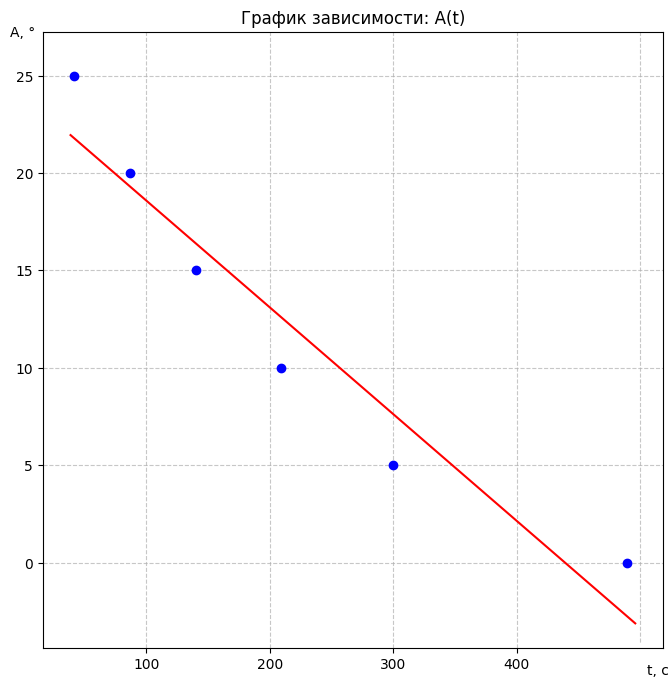

In [23]:
A_lin_DMM = DrawableMultipleMeasurement(t_average_exp2, A_lin)
A_lin_DMM.plot_MKN(
    x_name='t', x_unit='c', y_name='A', y_unit='°', pad_x=1.35, pad_y=1.65, 
    error_X=False, error_Y=False, label=None)

##### График зависимости $ln(\frac{A}{A_0})(t)$ (линейный при вязком трении)

График зависимости: ln(A/A₀) = 0.13-0.0062t
Время выполнения = 0:00:00.007579


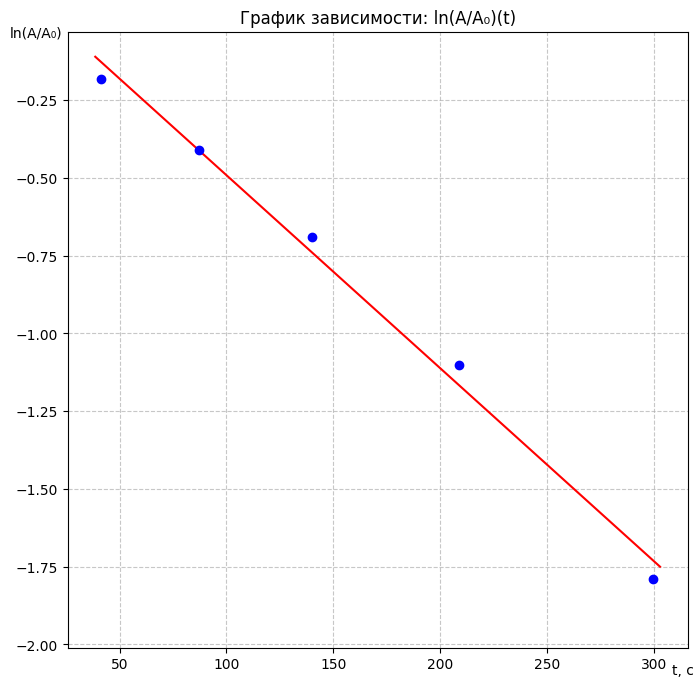

In [24]:
A_log_DMM = DrawableMultipleMeasurement(t_average_exp2[:-1], A_log)
A_log_DMM.plot_MKN(
    x_name='t', x_unit='c', y_name='ln(A/A₀)', y_unit='', pad_x=0, pad_y=1.65, 
    error_X=False, error_Y=False, label=None)

##### Выводы из зависимостей

Преобладает вязкое трение, т.к. график $ln\frac{A}{A_0}(t)$ больше похож на линейный (и посчитан с меньшей относительной погрешностью)

In [25]:
print(A_lin_DMM.info)
print(A_log_DMM.info)

y = a + bx: y = 24-0.055x
a = 24±4 ε = 17.0 (24.059246566132 Δ = 4.106731173 ε = 17.069242636)
b = -0.055±0.016 ε = 29.0 (-0.054796143949 Δ = 0.015877137 ε = 28.974916872)
y = a + bx: y = 0.13-0.0062x
a = 0.13±0.12 ε = 90.0 (0.129032884511 Δ = 0.120480626 ε = 93.372032185)
b = -0.0062±0.0007 ε = 11.0 (-0.006201197407 Δ = 0.000668719 ε = 10.783711125)


##### Для сухого (не моё)

Выражение (по формуле 17 и зависимости):
$A(nT) = A_0−4n\Delta\varphi_z = A + B \cdot nT$

Ширина зоны застоя:
$\Delta\varphi_z = -\frac{B\cdot T}{4}$,
$\varepsilon_{\Delta\varphi_z} = \sqrt{(\frac{\Delta_B}{B})^2 + (\frac{\Delta_T}{T})^2} * 100\%$,
$\Delta_{\Delta\varphi_z} = \frac{\Delta\varphi_z * \varepsilon_{\Delta\varphi_z}}{100\%}$

Найдём $Z_\text{теор}$ через время до остановки
$0=A-B \cdot t_\text{ост} \implies t_\text{ост}=\frac{A}{B}$,

Количество периодов: 
$Z_\text{теор}=\frac{t_\text{ост}}{T} = \frac{A}{B \cdot T}$,
$\varepsilon_{Z_\text{теор}} = \sqrt{(\frac{\Delta_A}{A})^2 + (\frac{\Delta_B}{B})^2 + (\frac{\Delta_T}{T})^2} * 100\%$,
$\Delta_{Z_\text{теор}} = \frac{Z_\text{теор} * \varepsilon_{Z_\text{теор}}}{100\%}$

In [26]:
A, B = A_lin_DMM.a, A_lin_DMM.b
print('A =', A)
print('B =', B)
print('T =', T)
dfz = -0.25 * B.value_ * T.value_
DeltaPhiZ = Measurement(dfz, abs(dfz)*sqrt((B.delta_/B.value_)**2 + (T.delta_/T.value_)**2))
print('Ширина зоны застоя: ', DeltaPhiZ)

tz = A.value_ / B.value_ / T.value_
TheorZ = Measurement(tz, abs(tz)*sqrt((A.delta_/A.value_)**2 + (B.delta_/B.value_)**2 + (T.delta_/T.value_)**2))
print('Количество периодов: ', TheorZ)

A = 24±4 ε = 17.0 (24.059246566132 Δ = 4.106731173 ε = 17.069242636)
B = -0.055±0.016 ε = 29.0 (-0.054796143949 Δ = 0.015877137 ε = 28.974916872)
T = 1.823±0.004 ε = 0.24 (1.823 Δ = 0.004351373 ε = 0.238692963)
Ширина зоны застоя:  0.025±0.007 ε = 29.0 (0.024973342605 Δ = 0.007236251 ε = 28.975900021)
Количество периодов:  -240±80 ε = 34.0 (-240.849282239861 Δ = 80.997073843 ε = 33.629775887)


##### Для вязкого (моё!)

$\ln\frac{A}{A_0} = -\beta t = A + Bt$

Коэффициент затухания:
$\beta = -\frac{A}{t} - B \approx |B|$, 
$\Delta_\beta = \Delta_B$

Время затухания:
$\tau = \frac{1}{\beta}$,
$\varepsilon_\tau = \frac{\Delta_\beta}{\beta} * 100\%$,
$\Delta_\tau = \frac{\tau * \varepsilon_\tau}{100\%} = \frac{\tau * \Delta_\beta}{\beta}$

In [27]:
B = A_log_DMM.b
beta = Measurement(-B.value_, B.delta_)
print('Коэффициент затухания: ', beta)
tau_value = 1 / beta.value_
tau = Measurement(tau_value, abs(tau_value * beta.delta_ / beta.value_))
print('Время затухания: ', tau)

Коэффициент затухания:  0.0062±0.0007 ε = 11.0 (0.006201197407 Δ = 0.000668719 ε = 10.783711125)
Время затухания:  161±17 ε = 11.0 (161.259178572939 Δ = 17.389723980 ε = 10.783711125)


### 2 задание

##### Квадрат периода

$T = \frac{t}{5}, \Delta_T=\frac{\Delta_t}{5}$

$T^2, \Delta_{T^2}=2t\Delta_t$

In [28]:
# phi_start_exp3, N_exp3, direct_exp3
T_exp3 = {}
TQ_exp3 = {}
for k, v in direct_exp3.items():
    T_exp3[k] = Measurement(v.value_ / N_exp3, v.delta_ / N_exp3)
    TQ_exp3[k] = Measurement(T_exp3[k].value_**2, abs(2*T_exp3[k].value_*T_exp3[k].delta_))
print('Периоды при разных положениях грузов')
pprint(T_exp3)
print('Квадраты периодов при разных положениях грузов')
pprint(TQ_exp3)

Периоды при разных положениях грузов
{0.5: 1.566±0.018 ε = 1.1,
 1: 1.597±0.025 ε = 1.5,
 2: 1.6953±0.0032 ε = 0.19,
 3: 1.814±0.015 ε = 0.8,
 4: 1.917±0.025 ε = 1.3,
 5: 2.075±0.015 ε = 0.7,
 5.5: 2.171±0.012 ε = 0.5,
 6: 2.229±0.010 ε = 0.5,
 6.5: 2.369±0.010 ε = 0.4}
Квадраты периодов при разных положениях грузов
{0.5: 2.45±0.06 ε = 2.3,
 1: 2.55±0.08 ε = 3.1,
 2: 2.874±0.011 ε = 0.37,
 3: 3.29±0.05 ε = 1.6,
 4: 3.7±0.1 ε = 2.6,
 5: 4.30±0.06 ε = 1.5,
 5.5: 4.71±0.05 ε = 1.1,
 6: 4.97±0.05 ε = 0.9,
 6.5: 5.61±0.05 ε = 0.9}


##### Растояния до центра

Для груза, расположенного краем на риске n расстояние до центра вычисляется как:

$R = l_1 + (n-1)l_0 + \frac{b}{2}$

$\Delta_R = \frac{2}{3}\sqrt{(\Delta_{l_1})^2 + ((n-1)\Delta_{l_0})^2 + (\frac{1}{2}\Delta_{b})^2}$

Верхний груз на (спица со стрелкой) на $n_\text{верх}=1$ риске, а нижний (противоположный) на $n_\text{ниж}=6$:

$I_\text{гр}=m_\text{гр}(R_\text{верх}^2 + R_\text{ниж}^2 + 2R_\text{бок}^2 + \frac{b^2}{3}) = m_\text{гр}*S$ (формула 9.1)

$S = R_\text{верх}^2 + R_\text{ниж}^2 + 2R_\text{бок}^2 + \frac{b^2}{3}$

$\Delta_S = \sqrt{(2R_\text{верх}\Delta_{R_\text{верх}})^2 + (2R_\text{низ}\Delta_{R_\text{низ}})^2 + (4R_\text{бок}\Delta_{R_\text{бок}})^2 + (\frac{4b\Delta_b}{9})^2}$

$\varepsilon_{I_\text{гр}} = \sqrt{(\frac{\Delta_{m_\text{гр}}}{m_\text{гр}})^2 + (\frac{\Delta_{S}}{S})^2} = \sqrt{(\frac{\Delta_{m_\text{гр}}}{m_\text{гр}})^2 + (\frac{2R_\text{верх}\Delta_{R_\text{верх}}}{S})^2 + (\frac{2R_\text{низ}\Delta_{R_\text{низ}}}{S})^2 + (\frac{4R_\text{бок}\Delta_{R_\text{бок}}}{S})^2 + (\frac{4b\Delta_b}{9S})^2} \cdot 100 \%$

$\Delta_{I_\text{гр}} = \frac{I_\text{гр} \cdot \varepsilon_{I_\text{гр}}}{100\%}$

In [29]:
def R(n: int):
    # global l_0, l_1, b_cargo
    return Measurement(
        l_1.value_ + (n - 1)*l_0.value_ + (b_cargo.value_ / 2),
        (2/3)*sqrt(l_1.delta_**2 + ((n-1)*l_0.delta_)**2 + (0.5*b_cargo.delta_)**2 )
    )

R_up = R(1)
print("R_up", R_up)
R_down = R(6)
print("R_down", R_down)

R_boks = {}
I_cargo = {}
for n in direct_exp3.keys():
    print(f'=== {n} РИСОК ===')
    R_bok = R(n)
    print('R бок =', R_bok)
    S = Measurement(
        R_up.value_**2 + R_down.value_**2 + 2*R_bok.value_**2 + b_cargo.value_**2/3, 
        sqrt((2*R_up.value_*R_up.delta_)**2 + (2*R_down.value_*R_down.delta_)**2 
             + (2*R_bok.value_*R_bok.delta_)**2 + (4*b_cargo.value_*b_cargo.delta_/9)**2)
    )
    vig = m_cargo.value_ * S.value_
    I = Measurement(vig, vig * sqrt( (m_cargo.delta_/m_cargo.value_)**2 + (S.delta_/S.value_)**2))
    print('I гр =', I)
    R_boks[n] = R_bok
    I_cargo[n] = I
    
pprint(I_cargo)
    

R_up 0.07700±0.00014 ε = 0.18 (0.077 Δ = 0.000137437 ε = 0.178489421)
R_down 0.2030±0.0007 ε = 0.34 (0.203 Δ = 0.000680686 ε = 0.335313265)
=== 0.5 РИСОК ===
R бок = 0.06440±0.00015 ε = 0.24 (0.0644 Δ = 0.000152753 ε = 0.237193359)
I гр = 0.02244±0.00016 ε = 0.7 (0.022442387387 Δ = 0.000157939 ε = 0.703751315)
=== 1 РИСОК ===
R бок = 0.07700±0.00014 ε = 0.18 (0.077 Δ = 0.000137437 ε = 0.178489421)
I гр = 0.02387±0.00016 ε = 0.7 (0.023871262667 Δ = 0.000163097 ε = 0.683234827)
=== 2 РИСОК ===
R бок = 0.10220±0.00019 ε = 0.19 (0.1022 Δ = 0.000191485 ε = 0.187363426)
I гр = 0.02749±0.00018 ε = 0.6 (0.027492966347 Δ = 0.000177207 ε = 0.644554171)
=== 3 РИСОК ===
R бок = 0.12740±0.00030 ε = 0.24 (0.1274 Δ = 0.000300000 ε = 0.235478807)
I гр = 0.03213±0.00020 ε = 0.6 (0.032133274187 Δ = 0.000197429 ε = 0.614406879)
=== 4 РИСОК ===
R бок = 0.1526±0.0004 ε = 0.28 (0.1526 Δ = 0.000422953 ε = 0.277164210)
I гр = 0.03779±0.00022 ε = 0.6 (0.037792186187 Δ = 0.000224859 ε = 0.594986788)
=== 5 РИСОК

##### Зависимость $T^2$ колебаний маятника от $I_\text{гр}$:

$T^2 = \frac{4\pi^2}{mgl}I_\text{гр} + \frac{4\pi^2}{mgl}I_0 = B \cdot I_\text{гр} + A$

I гр = [0.02244±0.00016 ε = 0.7, 0.02387±0.00016 ε = 0.7, 0.02749±0.00018 ε = 0.6, 0.03213±0.00020 ε = 0.6, 0.03779±0.00022 ε = 0.6, 0.04447±0.00026 ε = 0.6, 0.04819±0.00028 ε = 0.6, 0.05217±0.00030 ε = 0.6, 0.05640±0.00033 ε = 0.6]
T² = [2.45±0.06 ε = 2.3, 2.55±0.08 ε = 3.1, 2.874±0.011 ε = 0.37, 3.29±0.05 ε = 1.6, 3.7±0.1 ε = 2.6, 4.30±0.06 ε = 1.5, 4.71±0.05 ε = 1.1, 4.97±0.05 ε = 0.9, 5.61±0.05 ε = 0.9]
График зависимости: T² = 0.4+90I гр
Время выполнения = 0:00:00.010002
y = a + bx: y = 0.4+90x
a = 0.40±0.10 ε = 26.0 (0.395054793009 Δ = 0.101514195 ε = 25.696231653)
b = 90±5 ε = 6.0 (89.522213853543 Δ = 5.059608483 ε = 5.651791064)


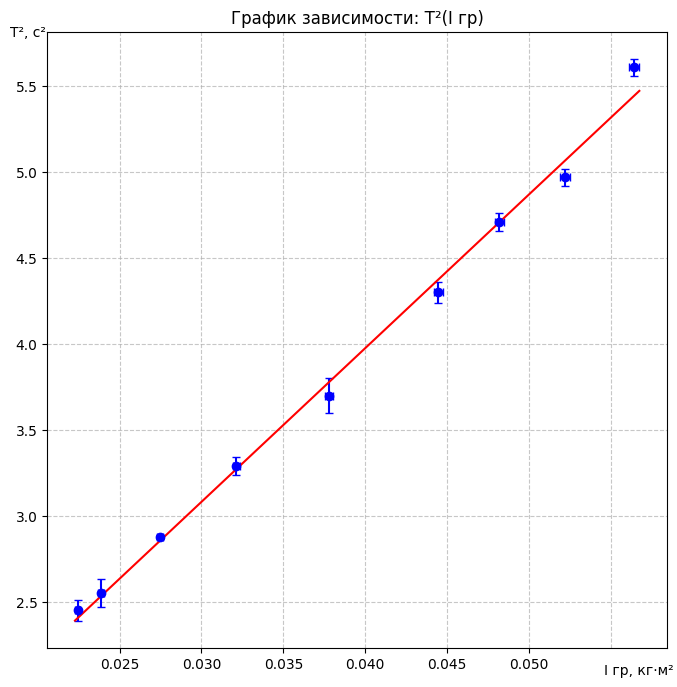

In [30]:
print('I гр =', list(I_cargo.values()))
print('T² =', list(TQ_exp3.values()))
I_T = DrawableMultipleMeasurement(list(I_cargo.values()), list(TQ_exp3.values()))
I_T.plot_MKN(
    y_name='T²', y_unit='c²', x_name='I гр', x_unit='кг⋅м²', pad_x=1, pad_y=1.65, 
    error_X=True, error_Y=True, label=None)

I_T.a._delta_ /= 2
I_T.a._epsilon_ /= 2
I_T.a._calc()
I_T.a._round()

print(I_T.info)

Большая погрешность свободного члена (50%) обусловлена малым вкладом $I_0$ в общий момент инерции и накоплением погрешностей измерений.

Экспериментальные данные подтверждают применимость формул (8) и (18) для описания колебаний маятника. Несмотря на большую погрешность свободного члена, модель остаётся достоверной, так как угловой коэффициент согласуется с теорией.

##### Экспериментальный $I_0$ и $ml$

Из зависимости: $T^2(I_\text{гр}) = \frac{4\pi^2}{mgl}I_\text{гр} + \frac{4\pi^2}{mgl}I_0 = B \cdot I_\text{гр} + A$

Значение $ml$ через угловой коэффициент:

$B = \frac{4\pi^2}{mgl} \implies ml = \frac{4\pi^2}{gB}$

$\varepsilon_{ml} = \frac{\Delta_B}{B} \cdot 100\% = \varepsilon_{B}$, $\Delta_{ml} = \frac{ml \varepsilon_{ml}}{100\%} = \frac{ml\Delta_B}{B}$

Значение $I_o$ через A и B:

$I_0 = \frac{A}{B}$

- $m$ - масса маятника
- $l$ - расстояние от оси подвеса до центра масс
- $g_\text{СПб} = 9,8195 м/с^2$
- $I_0$ - момент инерции крестовины и ступицы

In [31]:
A, B = I_T.a, I_T.b

g = 9.8195
vml = (4 * pi**2) / (g * B.value_)
ml_exp = Measurement(vml, vml * B.delta_ / B.value_)
print("Значение ml =", ml_exp)
print(ml_exp.latex_full)

vI0 = A.value_ / B.value_
eI0 = sqrt(A.epsilon_**2 + B.epsilon_**2)
I_0_exp = Measurement(vI0, vI0 * eI0 / 100)
print("Эксперементальный I0 =", I_0_exp)
print(I_0_exp.latex_full)

Значение ml = 0.0449±0.0025 ε = 6.0 (0.044909637405 Δ = 0.002538199 ε = 5.651791064)
$0.0449\pm0.0025, \varepsilon = 6.0\%$
Эксперементальный I0 = 0.0044±0.0012 ε = 26.0 (0.004412924748 Δ = 0.001161060 ε = 26.310436397)
$0.0044\pm0.0012, \varepsilon = 26.0\%$


##### Расчёт теоретического значения $I_0$

Ступица - цилиндр, ось вращения через центр вращения.

$I_\text{ступ} = \frac{1}{2}m_\text{ступ}R_\text{ступ}^2$

$\Delta_{I_\text{ступ}} = I_\text{ступ} \cdot \sqrt{(\frac{\Delta_{m_\text{ступ}}}{m_\text{ступ}})^2 + (\frac{2\Delta_{R_\text{ступ}}}{R_\text{ступ}})^2}$

Стержень, закреплённый на расстоянии $r_\text{стер}$ от оси вращения через конец, перпендикулярный оси вращения.

$I_\text{стер} = \frac{mL^2}{3} + mr^2 = I_1 + I_2$

$\Delta_{I_\text{стер}} = \sqrt{I_1^2((\frac{\Delta_m}{m})^2 + (\frac{\Delta_L}{L})^2) + I_2^2((\frac{\Delta_m}{m})^2 + (\frac{\Delta_r}{r})^2)}$

Момент инерции конструкции маятника

$I_0 = 4I_\text{стер} + I_\text{ступ}$

Погрешность $I_0$:

$\Delta_{I_0} = \sqrt{16\Delta_{I_\text{стер}}^2 + \Delta_{I_\text{ступ}}^2}$

In [37]:
vIhub = (1/2) * m_hub.value_ * r_hub.value_**2
dIhub = vIhub * sqrt((m_hub.delta_/m_hub.value_)**2 + (r_hub.delta_/r_hub.value_)**2)
I_hub = Measurement(vIhub, dIhub)
print("Момент инерции ступицы =", I_hub)
print(I_hub.latex_full)

vI1, vI2 = m_rod.value_ * L_rod.value_**2 / 3, m_rod.value_ * r_rod.value_**2
vIrod = vI1 + vI2
dIrod = sqrt(vI1**2 * ((m_rod.delta_/m_rod.value_)**2 + (L_rod.delta/L_rod.value_)**2) +
             vI2**2 * ((m_rod.delta_/m_rod.value_)**2 + (r_rod.delta/r_rod.value_)**2))
I_rod = Measurement(vIrod, dIrod)
print("Момент инерции стержня =", I_rod)
print(I_rod.latex_full)

I_0_theor = Measurement(4*I_rod.value_ + I_hub.value_, sqrt(16*I_rod.delta_**2 + I_hub.delta_**2))
print("Теоретический I0 =", I_0_theor)
print(I_0_theor.latex_full)

Момент инерции ступицы = 0.000113±0.000001 ε = 0.8 (0.000113184 Δ = 0.000000954 ε = 0.842989334)
$0.000113\pm0.000001, \varepsilon = 0.8\%$
Момент инерции стержня = 0.001592±0.000014 ε = 0.9 (0.001592041667 Δ = 0.000014310 ε = 0.898877218)
$0.001592\pm0.000014, \varepsilon = 0.9\%$
Теоретический I0 = 0.00648±0.00006 ε = 0.9 (0.006481350667 Δ = 0.000057250 ε = 0.883302781)
$0.00648\pm0.00006, \varepsilon = 0.9\%$


##### Вывод 2 задания

In [33]:
print("Эксперементальный I0 =", I_0_exp)
print("Теоретический I0 =", I_0_theor)

Эксперементальный I0 = 0.0044±0.0012 ε = 26.0 (0.004412924748 Δ = 0.001161060 ε = 26.310436397)
Теоретический I0 = 0.00648±0.00006 ε = 0.9 (0.006481350667 Δ = 0.000057250 ε = 0.883302781)


В нашем случае слагаемым с $b$ можно пренебречь. Однако при работе с более крупными грузами его следует учитывать.

### 3 задание

$ml = m_{\text{низ}} R_{\text{низ}} - m_{\text{верх}} R_{\text{верх}}$

$\Delta_{ml} = \sqrt{ \left( R_{\text{ниж}} \Delta m_{\text{ниж}} \right)^2 + \left( m_{\text{ниж}} \Delta R_{\text{ниж}} \right)^2 + \left( R_{\text{верх}} \Delta m_{\text{верх}} \right)^2 + \left( m_{\text{верх}} \Delta R_{\text{верх}} \right)^2 }$

$ml = m_{\text{гр}} ( R_{\text{низ}} - R_{\text{верх}} )$

$\Delta_{ml} = \sqrt{ (R_{\text{ниж}}^2 + R_{\text{верх}}^2)(\Delta m_{\text{гр}})^2 + m_{\text{гр}}^2 (\Delta R_{\text{ниж}}^2 + \Delta R_{\text{верх}}^2) }$

In [38]:
ml_theor = Measurement(
    m_cargo.value_ * (R_down.value_ - R_up.value_),
    sqrt( (R_down.value_**2 + R_up.value_**2)*m_cargo.delta_**2 + (R_down.delta_**2 + R_up.delta_**2)*m_cargo.value_**2 )
)

print(ml_theor.latex_full)

print('Теоретическое значение ml =', ml_theor)
print('Экспериментальное значение ml =', ml_exp)

delta_ml = round(abs(ml_theor.value - ml_exp.value), 12)
print('Разница', delta_ml)
print(f'Относительно теоретического {delta_ml/ml_exp.value*100:.2f}%')

$0.0505\pm0.0005, \varepsilon = 1.0\%$
Теоретическое значение ml = 0.0505±0.0005 ε = 1.0 (0.050526 Δ = 0.000515843 ε = 1.020945297)
Экспериментальное значение ml = 0.0449±0.0025 ε = 6.0 (0.044909637405 Δ = 0.002538199 ε = 5.651791064)
Разница 0.0056
Относительно теоретического 12.47%


# LaTeX

In [35]:
c8 = xml.findall('c8')

chapter8 = (
    next(c8) + direct_t._measurments[0].latex + 
    next(c8) + direct_t._measurments[1].latex + 
    next(c8) + direct_t._measurments[2].latex + next(c8)
)
# Таблица 2
for i in range(len(direct_exp2)):
    for j in range(len(direct_exp2[i])):
        chapter8 += str(direct_exp2[i][j]) + next(c8)
for x in t_average_exp2:
    chapter8 += x.latex + next(c8)
# Таблица 3
for x, y in zip(direct_exp3.values(), T_exp3.values()):
    chapter8 += (
        str(x.measurments[0].value) + next(c8) + 
        str(x.measurments[1].value) + next(c8) + 
        str(x.measurments[2].value) + next(c8) + 
        x.latex + next(c8) + y.latex + next(c8)
    )

print(chapter8)


Результаты измерения $N=10$ колебаний маятника из положения $\varphi_\text{шк}=0$:
\begin{equation*}
    t_1=$18.210\pm0.010$c, t_2=$18.240\pm0.010$c, t_3=$18.240\pm0.010$c
\end{equation*}

В таблице \ref{tab:meas2} представлены результаты 3х измерений времени затухания, количество колебаний до полной остановки маятника $Z_\text{эксп}=...$.

\begin{table}[H]
\centering
\caption{Время затухания до определённой амплитуды отклонения $\varphi_\text{шк}$}
\label{tab:meas2}
\begin{tabular}{|c|c|c|c|c|c|c|}
\hline
\begin{tabular}[x]{@{}c@{}}Амплитуда\\отклонения\\Время\end{tabular} & $25^{\circ}$ & $20^{\circ}$ & $15^{\circ}$ & $10^{\circ}$ & $5^{\circ}$ & $0^{\circ}$ \\ \hline
$t_1, c$ & 40.4 & 83.97 & 137.03 & 206.86 & 298.28 & 491.66 \\ \hline
$t_2, c$ & 40.58 & 88.05 & 141.0 & 211.54 & 299.46 & 486.34 \\ \hline
$t_3, c$ & 42.2 & 87.7 & 140.71 & 209.64 & 301.02 & 488.55 \\ \hline
$\bar{t}, c$ & $41.1\pm2.5$ & $87\pm6$ & $140\pm5$ & $209\pm6$ & $299.6\pm3.4$ & $489\pm7$ \\ \hline
\end{tabu

In [36]:
t4 = xml.findall('t4')
table4 = next(t4)

for x, y ,z in zip(R_boks.values(), I_cargo.values(), TQ_exp3.values()):
    table4 += x.latex + next(t4) + y.latex + next(t4) + z.latex + next(t4)
    
print(table4)


\begin{table}[ht]
\centering
\caption{Определение характеристик маятника}\label{tab:cosmeas}
\begin{tabular}{|c|c|c|c|}
\hline
\textbf{Риски} & $R_{\text{бок}}, \text{м}$ & $I_{\text{гр}}, \text{кг}\cdot\text{м}^2$ & $T^2, \text{c}^2$ \\ 
\hline
0.5 & $0.06440\pm0.00015$ & $0.02244\pm0.00016$ & $2.45\pm0.06$ \\ \hline
1   & $0.07700\pm0.00014$ & $0.02387\pm0.00016$ & $2.55\pm0.08$ \\ \hline
2   & $0.10220\pm0.00019$ & $0.02749\pm0.00018$ & $2.874\pm0.011$ \\ \hline
3   & $0.12740\pm0.00030$ & $0.03213\pm0.00020$ & $3.29\pm0.05$ \\ \hline
4   & $0.1526\pm0.0004$ & $0.03779\pm0.00022$ & $3.7\pm0.1$ \\ \hline
5   & $0.1778\pm0.0006$ & $0.04447\pm0.00026$ & $4.30\pm0.06$ \\ \hline
5.5 & $0.1904\pm0.0006$ & $0.04819\pm0.00028$ & $4.71\pm0.05$ \\ \hline
6   & $0.2030\pm0.0007$ & $0.05217\pm0.00030$ & $4.97\pm0.05$ \\ \hline
6.5 & $0.2156\pm0.0007$ & $0.05640\pm0.00033$ & $5.61\pm0.05$ \\ \hline
\end{tabular}
\end{table}

